In [105]:
import os
import io
import tarfile

import urllib.request

import numpy as np

import astropy.units as u

from astropy.io import fits
from astropy.table import Table
from astropy.coordinates import SkyCoord
from astroquery.heasarc import Heasarc

heasarc = Heasarc()

clusters = ['A85', 'A426', 'A1644', 'A1656', 'A2029','A3158']

In [120]:
def retrieve(target):
    print('getting simbad coordinates for target object...\n')

    coord = SkyCoord.from_name(target)

    print('searching chandra catalog in given region...\n')

    results = heasarc.query_region(coord, catalog='chanmaster', radius=15 * u.arcmin)
    results.sort('exposure')
    results.reverse()

    print('results from chandra catalog in given region:\n')

    print(results['obsid', 'exposure', 'ra', 'dec'][:10])
    
    best_obsid = str(results['obsid'][0])

    base_url = f'https://heasarc.gsfc.nasa.gov/FTP/chandra/data/byobsid/{best_obsid[-1]}/{best_obsid}/primary/'

    filename_0 = f'acisf{best_obsid.zfill(5)}N000_evt2.fits.gz'
    filename_1 = f'acisf{best_obsid.zfill(5)}N001_evt2.fits.gz'
    filename_2 = f'acisf{best_obsid.zfill(5)}N002_evt2.fits.gz'
    filename_3 = f'acisf{best_obsid.zfill(5)}N003_evt2.fits.gz'
    filename_4 = f'acisf{best_obsid.zfill(5)}N004_evt2.fits.gz'
    filename_5 = f'acisf{best_obsid.zfill(5)}N005_evt2.fits.gz'
    filename_6 = f'acisf{best_obsid.zfill(5)}N006_evt2.fits.gz'
    filename_7 = f'acisf{best_obsid.zfill(5)}N007_evt2.fits.gz'
    filename_8 = f'acisf{best_obsid.zfill(5)}N008_evt2.fits.gz'
    filename_9 = f'acisf{best_obsid.zfill(5)}N009_evt2.fits.gz'

    download = True

    if os.path.exists('catalog/Chandra/' + filename_0):
        filename = filename_0
        print('\nmatching file found, skipping download.\n')
    elif os.path.exists('catalog/Chandra/' + filename_1):
        filename = filename_1
        print('\nmatching file found, skipping download.\n')
    elif os.path.exists('catalog/Chandra/' + filename_2):
        filename = filename_2
        print('\nmatching file found, skipping download.\n')
    elif os.path.exists('catalog/Chandra/' + filename_3):
        filename = filename_3
        print('\nmatching file found, skipping download.\n')
    elif os.path.exists('catalog/Chandra/' + filename_4):
        filename = filename_4
        print('\nmatching file found, skipping download.\n')
    elif os.path.exists('catalog/Chandra/' + filename_5):
        filename = filename_5
        print('\nmatching file found, skipping download.\n')
    elif os.path.exists('catalog/Chandra/' + filename_6):
        filename = filename_6
        print('\nmatching file found, skipping download.\n')
    elif os.path.exists('catalog/Chandra/' + filename_7):
        filename = filename_7
        print('\nmatching file found, skipping download.\n')
    elif os.path.exists('catalog/Chandra/' + filename_8):
        filename = filename_8
        print('\nmatching file found, skipping download.\n')
    elif os.path.exists('catalog/Chandra/' + filename_9):
        filename = filename_9
        print('\nmatching file found, skipping download.\n')
    else:
        try:
            print('\nattempting download...\n')
            filename = filename_0
            download_url = base_url + filename
            urllib.request.urlretrieve(full_download_url, 'catalog/Chandra/' + filename)
        except:
            try:
                print('file not found, trying fallback...\n')
                filename = filename_1
                download_url = base_url + filename
                urllib.request.urlretrieve(download_url, 'catalog/Chandra/' + filename)
            except:
                try:
                    print('file not found, trying fallback...\n')
                    filename = filename_2
                    download_url = base_url + filename
                    urllib.request.urlretrieve(download_url, 'catalog/Chandra/' + filename)
                except:
                    try:
                        print('file not found, trying fallback...\n')
                        filename = filename_3
                        download_url = base_url + filename
                        urllib.request.urlretrieve(download_url, 'catalog/Chandra/' + filename)
                    except:
                        try:
                            print('file not found, trying fallback...\n')
                            filename = filename_4
                            download_url = base_url + filename
                            urllib.request.urlretrieve(download_url, 'catalog/Chandra/' + filename)
                        except:
                            try:
                                print('file not found, trying fallback...\n')
                                filename = filename_5
                                download_url = base_url + filename
                                urllib.request.urlretrieve(download_url, 'catalog/Chandra/' + filename)
                            except:
                                try:
                                    print('file not found, trying fallback...\n')
                                    filename = filename_6
                                    download_url = base_url + filename
                                    urllib.request.urlretrieve(download_url, 'catalog/Chandra/' + filename)
                                except:
                                    try:
                                        print('file not found, trying fallback...\n')
                                        filename = filename_7
                                        download_url = base_url + filename
                                        urllib.request.urlretrieve(download_url, 'catalog/Chandra/' + filename)
                                    except:
                                        try:
                                            print('file not found, trying fallback...\n')
                                            filename = filename_8
                                            download_url = base_url + filename
                                            urllib.request.urlretrieve(download_url, 'catalog/Chandra/' + filename)
                                        except:
                                            try:
                                                print('file not found, trying fallback...\n')
                                                filename = filename_9
                                                download_url = base_url + filename
                                                urllib.request.urlretrieve(download_url, 'catalog/Chandra/' + filename)
                                            except:
                                                download = False
                                                print('download failed, aborting...')

    if download:
        print('extracting binned spectrum...\n')
        with fits.open('catalog/Chandra/' + filename) as hdul:
            data = hdul[1].data
            header = hdul[1].header
        
            exposure = header.get('EXPOSURE', 1.0)
        
            energies = data['energy'] / 1000.0
        
            edges = np.linspace(2.0, 10.0, 501)
            counts, _ = np.histogram(energies, bins=edges)
        
            centers = (edges[:-1] + edges[1:]) / 2.0
            widths = np.diff(edges)
            
            flux = counts / (exposure * widths)
            error = np.sqrt(counts) / (exposure * widths)
        
            mask = flux > 0
        
            centers = centers[mask]
            flux = flux[mask]
            error = error[mask]
    
            output_file = f'{filename[:-8]}-{target}.txt'
            
            np.savetxt('catalog/Chandra/' + output_file, np.column_stack((centers, flux, error)), header='E / keV # rel_F # rel_F_err #')
        print('done.')

In [121]:
def extract(target):
    data = {'density': None, 'temperature': None, 'fgas': None}

    print('streaming data from archive...\n')

    with tarfile.open('catalog/XMM-Newton/X-COP.tar.gz', 'r:gz') as tar:
        for member in tar.getmembers():
            if target in member.name and member.isfile() and member.name.endswith(".fits"):
                
                file_bytes = tar.extractfile(member).read()
                byte_stream = io.BytesIO(file_bytes)
                
                if 'density' in member.name:
                    data['density'] = Table.read(byte_stream, format='fits')
                elif 'temperature' in member.name:
                    data['temperature'] = Table.read(byte_stream, format='fits')
                elif 'fgas' in member.name:
                    data['fgas'] = Table.read(byte_stream, format='fits')

    if data['density'] is not None:
        tab = data['density']

        print('saving density data...\n')

        R = (tab['R_IN'] + tab['R_OUT']) / 2.0
        ne = tab['NE']
        ne_err_lo = np.abs(tab['NE'] - tab['NE_LOW'])
        ne_err_hi = np.abs(tab['NE'] - tab['NE_HIGH'])
    
        output_file = f'X-COM-{target}-dens.txt'
    
        np.savetxt('catalog/XMM-Newton/' + output_file,
                   np.column_stack((R, ne, ne_err_lo, ne_err_hi)),
                   header='R / kpc # ne / cm-3 # ne_err_lo / cm-3 # ne_err_hi / cm-3 #')
    else:
        print('no density data found...\n')

    if data['temperature'] is not None:
        tab = data['temperature']

        print('saving temperature data...\n')
        
        R = tab['RW_X']
        T = tab['T_X']
        T_err = tab['eT_X']
    
        output_file = f'X-COM-{target}-temp.txt'
    
        np.savetxt('catalog/XMM-Newton/' + output_file,
                   np.column_stack((R, T, T_err)),
                   header='R/R500 # T/Tavg # T_err/Tavg #')
    else:
        print('no temperature data found...\n')

    if data['fgas'] is not None:
        tab = data['fgas']

        print('saving fgas data...\n')
    
        R = tab['RADIUS']
        fgas = tab['FGAS']
        fgas_err_lo = np.abs(tab['FGAS'] - tab['FGAS_LO'])
        fgas_err_hi = np.abs(tab['FGAS'] - tab['FGAS_HI'])
    
        output_file = f'X-COM-{target}-fgas.txt'
    
        np.savetxt('catalog/XMM-Newton/' + output_file,
                   np.column_stack((R, fgas, fgas_err_lo, fgas_err_hi)),
                   header='R/R500 # fgas # fgas_err_lo # fgas_err_hi #')
    else:
        print('no fgas data found...\n')

    print('finished.')

In [122]:
print('---------------------------------------------')
for target in clusters:
    retrieve(target)
    print('---------------------------------------------')

---------------------------------------------
getting simbad coordinates for target object...

searching chandra catalog in given region...

results from chandra catalog in given region:

obsid exposure    ra      dec   
         s       deg      deg   
----- -------- -------- --------
15173    43080 10.42482 -9.34768
15174    40080 10.47191 -9.40945
  904    38910 10.44083 -9.37917
16263    38660 10.47191 -9.40945
16264    37080 10.42482 -9.34768
28689    29910 10.44486 -9.11320
28329    20090 10.44486 -9.11320
28688    20000 10.44486 -9.11320
30563    17590 10.44486 -9.11320
28686    17180 10.44486 -9.11320

matching file found, skipping download.

extracting binned spectrum...

done.
---------------------------------------------
getting simbad coordinates for target object...

searching chandra catalog in given region...

results from chandra catalog in given region:

obsid exposure    ra      dec   
         s       deg      deg   
----- -------- -------- --------
 4952   166420 49

In [123]:
print('---------------------------------------------')
for target in clusters:
    extract(target)
    print('---------------------------------------------')

---------------------------------------------
streaming data from archive...

saving density data...

saving temperature data...

saving fgas data...

finished.
---------------------------------------------
streaming data from archive...

no density data found...

no temperature data found...

no fgas data found...

finished.
---------------------------------------------
streaming data from archive...

saving density data...

saving temperature data...

saving fgas data...

finished.
---------------------------------------------
streaming data from archive...

no density data found...

no temperature data found...

no fgas data found...

finished.
---------------------------------------------
streaming data from archive...

saving density data...

saving temperature data...

saving fgas data...

finished.
---------------------------------------------
streaming data from archive...

saving density data...

saving temperature data...

saving fgas data...

finished.
----------------------

In [69]:
import io
import tarfile
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table

# Update this path to point to your data archive
tar_path = "chandra/allfiles.tar.gz"

def preview_and_load_tables(tar_filepath):
    """
    Scans the tar.gz archive for pre-computed profile tables,
    prints structural information, and returns valid parsed Astropy Tables.
    """
    extracted_tables = {}
    
    with tarfile.open(tar_filepath, "r:gz") as tar:
        for member in tar.getmembers():
            # Targets common pipeline names: profile.fits, sb_profile.dat, thermo_profiles.txt, etc.
            if any(k in member.name.lower() for k in ["profile", "density", "temperature", "sb_"]) and member.isfile():
                print(f"📦 Found precomputed data table: {member.name}")
                
                # Extract file contents directly into a byte buffer
                file_bytes = tar.extractfile(member).read()
                byte_stream = io.BytesIO(file_bytes)
                
                try:
                    # Astropy dynamically handles FITS binary tables, CSVs, and space-separated ASCII
                    if member.name.endswith(".fits"):
                        t = Table.read(byte_stream, format="fits")
                    else:
                        t = Table.read(byte_stream, format="ascii")
                    
                    extracted_tables[member.name] = t
                    print(f"   ↳ Success. Columns found: {t.colnames}\n")
                except Exception as e:
                    print(f"   ↳ Could not automatically parse file layout: {e}\n")
                    
    return extracted_tables

# Execute search over the compressed archive
tables = preview_and_load_tables(tar_path)

# =====================================================================
# SIMULATION FALLBACK (Runs ONLY if your archive is missing the files)
# =====================================================================
if not tables:
    print("⚠️ No matching table filenames found. Generating a mock X-COP table for visualization.")
    mock_data = Table()
    mock_data['RADIUS'] = np.logspace(1, 3.2, 25) # Radius in arcsec / kpc
    mock_data['SB'] = 1e-2 * (1 + (mock_data['RADIUS']/150)**2)**(-3*0.62 + 0.5)
    mock_data['SB_ERR'] = mock_data['SB'] * 0.05
    mock_data['KT'] = 7.5 * (1 + 0.5 * (mock_data['RADIUS']/400)) / (1 + (mock_data['RADIUS']/350)**2)**0.25
    mock_data['KT_ERR'] = mock_data['KT'] * 0.07
    mock_data['DENSITY'] = 3e-3 * (1 + (mock_data['RADIUS']/180)**2)**(-1.5*0.65)
    mock_data['DENSITY_ERR'] = mock_data['DENSITY'] * 0.09
    tables['mock_xcop_profile.fits'] = mock_data

# =====================================================================
# PLOTTING FROM EXTRACTED DATA STRUCT
# =====================================================================
# Target the first loaded or simulated table
active_filename = list(tables.keys())[0]
t = tables[active_filename]

# Map X-COP standard column variations to consistent script keys
r_col = [c for c in t.colnames if c.upper() in ['R', 'RADIUS', 'R_KPC', 'R_ARCSEC']][0]
sb_col = [c for c in t.colnames if c.upper() in ['SB', 'SURF_BRIGHT', 'FLUX', 'INTENSITY']][0]
t_col = [c for c in t.colnames if c.upper() in ['T', 'KT', 'TEMP', 'TEMPERATURE']][0]
n_col = [c for c in t.colnames if c.upper() in ['NE', 'DENSITY', 'N_E', 'RHO']][0]

# Locate associated error columns (defaulting to zero if missing)
sb_err = [c for c in t.colnames if sb_col in c and 'ERR' in c.upper()] or None
t_err = [c for c in t.colnames if t_col in c and 'ERR' in c.upper()] or None
n_err = [c for c in t.colnames if n_col in c and 'ERR' in c.upper()] or None

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Surface Brightness
y_err_sb = t[sb_err[0]] if sb_err else None
axs[0].errorbar(t[r_col], t[sb_col], yerr=y_err_sb, fmt='o-', color='indigo', capsize=2)
axs[0].set_yscale('log')
axs[0].set_xscale('log')
axs[0].set_xlabel(f"Radius ({r_col})")
axs[0].set_ylabel("Surface Brightness")
axs[0].grid(True, which="both", ls="--", alpha=0.5)
axs[0].set_title("Surface Brightness Profile")

# Plot 2: Temperature Profile
y_err_t = t[t_err[0]] if t_err else None
axs[1].errorbar(t[r_col], t[t_col], yerr=y_err_t, fmt='s-', color='darkorange', capsize=2)
axs[1].set_xscale('log')
axs[1].set_xlabel(f"Radius ({r_col})")
axs[1].set_ylabel("kT [keV]")
axs[1].grid(True, which="both", ls="--", alpha=0.5)
axs[1].set_title("Temperature Profile")

# Plot 3: Density Profile
y_err_n = t[n_err[0]] if n_err else None
axs[2].errorbar(t[r_col], t[n_col], yerr=y_err_n, fmt='^-', color='teal', capsize=2)
axs[2].set_yscale('log')
axs[2].set_xscale('log')
axs[2].set_xlabel(f"Radius ({r_col})")
axs[2].set_ylabel("Density [cm^-3]")
axs[2].grid(True, which="both", ls="--", alpha=0.5)
axs[2].set_title("Electron Density Profile")

plt.suptitle(f"Profiles Plotted Straight from Memory: {active_filename}", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

📦 Found precomputed data table: A1644/A1644_temperature.fits
   ↳ Success. Columns found: ['RW_X', 'T_X', 'eT_X']

📦 Found precomputed data table: A1644/A1644_fgas_profile.fits


   ↳ Success. Columns found: ['RADIUS', 'M_NFW', 'M_NFW_LO', 'M_NFW_HI', 'MGAS', 'MGAS_LO', 'MGAS_HI', 'FGAS', 'FGAS_LO', 'FGAS_HI']

📦 Found precomputed data table: A1644/A1644_fgas_profile.png
   ↳ Could not automatically parse file layout: 'utf-8' codec can't decode byte 0x89 in position 0: invalid start byte

📦 Found precomputed data table: A1644/A1644_density.png
   ↳ Could not automatically parse file layout: 'utf-8' codec can't decode byte 0x89 in position 0: invalid start byte

📦 Found precomputed data table: A1644/A1644_mass_profiles.png
   ↳ Could not automatically parse file layout: 'utf-8' codec can't decode byte 0x89 in position 0: invalid start byte

📦 Found precomputed data table: A1644/A1644_density_L1.fits
   ↳ Success. Columns found: ['R_IN', 'R_OUT', 'NE', 'NE_LOW', 'NE_HIGH']

📦 Found precomputed data table: A1644/A1644_temperature.png
   ↳ Could not automatically parse file layout: 'utf-8' codec can't decode byte 0x89 in position 0: invalid start byte

📦 Found prec

   ↳ Success. Columns found: ['R_IN', 'R_OUT', 'NE', 'NE_LOW', 'NE_HIGH']

📦 Found precomputed data table: A1795/A1795_temperature.fits
   ↳ Success. Columns found: ['RW_X', 'T_X', 'eT_X']

📦 Found precomputed data table: A1795/A1795_fgas_profile.fits
   ↳ Success. Columns found: ['RADIUS', 'M_NFW', 'M_NFW_LO', 'M_NFW_HI', 'MGAS', 'MGAS_LO', 'MGAS_HI', 'FGAS', 'FGAS_LO', 'FGAS_HI']

📦 Found precomputed data table: A1795/A1795_density.png
   ↳ Could not automatically parse file layout: 'utf-8' codec can't decode byte 0x89 in position 0: invalid start byte

📦 Found precomputed data table: A1795/A1795_mass_profiles.png
   ↳ Could not automatically parse file layout: 'utf-8' codec can't decode byte 0x89 in position 0: invalid start byte

📦 Found precomputed data table: A1795/A1795_mass_profiles.pdf
   ↳ Could not automatically parse file layout: 'utf-8' codec can't decode byte 0xac in position 10: invalid start byte

📦 Found precomputed data table: A1795/A1795_fgas_profile.png
   ↳ Could n

   ↳ Could not automatically parse file layout: 'utf-8' codec can't decode byte 0x89 in position 0: invalid start byte

📦 Found precomputed data table: A2029/A2029_mass_profiles.pdf
   ↳ Could not automatically parse file layout: 'utf-8' codec can't decode byte 0xac in position 10: invalid start byte

📦 Found precomputed data table: A2029/A2029_mass_profiles.png
   ↳ Could not automatically parse file layout: 'utf-8' codec can't decode byte 0x89 in position 0: invalid start byte

📦 Found precomputed data table: A2029/A2029_density.png
   ↳ Could not automatically parse file layout: 'utf-8' codec can't decode byte 0x89 in position 0: invalid start byte

📦 Found precomputed data table: A2029/A2029_temperature.png
   ↳ Could not automatically parse file layout: 'utf-8' codec can't decode byte 0x89 in position 0: invalid start byte

📦 Found precomputed data table: A2029/A2029_density_L1.fits
   ↳ Success. Columns found: ['R_IN', 'R_OUT', 'NE', 'NE_LOW', 'NE_HIGH']

📦 Found precomputed data

   ↳ Success. Columns found: ['RW_X', 'T_X', 'eT_X']

📦 Found precomputed data table: A2142/A2142_mass_profiles.pdf
   ↳ Could not automatically parse file layout: 'utf-8' codec can't decode byte 0xac in position 10: invalid start byte

📦 Found precomputed data table: A2142/A2142_mass_profiles.png
   ↳ Could not automatically parse file layout: 'utf-8' codec can't decode byte 0x89 in position 0: invalid start byte

📦 Found precomputed data table: A2142/A2142_temperature.fits
   ↳ Success. Columns found: ['RW_X', 'T_X', 'eT_X']

📦 Found precomputed data table: A2142/A2142_density.png
   ↳ Could not automatically parse file layout: 'utf-8' codec can't decode byte 0x89 in position 0: invalid start byte

📦 Found precomputed data table: A2142/A2142_fgas_profile.png
   ↳ Could not automatically parse file layout: 'utf-8' codec can't decode byte 0x89 in position 0: invalid start byte

📦 Found precomputed data table: A2142/A2142_fgas_profile.fits


...

   ↳ Success. Columns found: ['RADIUS', 'M_NFW', 'M_NFW_LO', 'M_NFW_HI', 'MGAS', 'MGAS_LO', 'MGAS_HI', 'FGAS', 'FGAS_LO', 'FGAS_HI']

📦 Found precomputed data table: A85/A85_temperature.fits
   ↳ Success. Columns found: ['RW_X', 'T_X', 'eT_X']

📦 Found precomputed data table: A85/A85_temperature.png
   ↳ Could not automatically parse file layout: 'utf-8' codec can't decode byte 0x89 in position 0: invalid start byte

📦 Found precomputed data table: A85/A85_density_L1.fits
   ↳ Success. Columns found: ['R_IN', 'R_OUT', 'NE', 'NE_LOW', 'NE_HIGH']

📦 Found precomputed data table: ZW1215/ZW1215_fgas_profile.png
   ↳ Could not automatically parse file layout: 'utf-8' codec can't decode byte 0x89 in position 0: invalid start byte

📦 Found precomputed data table: ZW1215/ZW1215_mass_profiles.png
   ↳ Could not automatically parse file layout: 'utf-8' codec can't decode byte 0x89 in position 0: invalid start byte

📦 Found precomputed data table: ZW1215/ZW1215_mass_profiles.pdf
   ↳ Could not au

   ↳ Success. Columns found: ['RW_X', 'T_X', 'eT_X']

📦 Found precomputed data table: ZW1215/ZW1215_fgas_profile.fits
   ↳ Success. Columns found: ['RADIUS', 'M_NFW', 'M_NFW_LO', 'M_NFW_HI', 'MGAS', 'MGAS_LO', 'MGAS_HI', 'FGAS', 'FGAS_LO', 'FGAS_HI']

📦 Found precomputed data table: ZW1215/ZW1215_density.png
   ↳ Could not automatically parse file layout: 'utf-8' codec can't decode byte 0x89 in position 0: invalid start byte

📦 Found precomputed data table: ZW1215/ZW1215_density_L1.fits
   ↳ Success. Columns found: ['R_IN', 'R_OUT', 'NE', 'NE_LOW', 'NE_HIGH']

📦 Found precomputed data table: ZW1215/ZW1215_temperature.png
   ↳ Could not automatically parse file layout: 'utf-8' codec can't decode byte 0x89 in position 0: invalid start byte

📦 Found precomputed data table: RXC1825/RXC1825_mass_profiles.png
   ↳ Could not automatically parse file layout: 'utf-8' codec can't decode byte 0x89 in position 0: invalid start byte

📦 Found precomputed data table: RXC1825/RXC1825_mass_profiles.pdf

   ↳ Success. Columns found: ['RW_X', 'T_X', 'eT_X']

📦 Found precomputed data table: RXC1825/RXC1825_fgas_profile.fits


   ↳ Success. Columns found: ['RADIUS', 'M_NFW', 'M_NFW_LO', 'M_NFW_HI', 'MGAS', 'MGAS_LO', 'MGAS_HI', 'FGAS', 'FGAS_LO', 'FGAS_HI']

📦 Found precomputed data table: RXC1825/RXC1825_density.png
   ↳ Could not automatically parse file layout: 'utf-8' codec can't decode byte 0x89 in position 0: invalid start byte

📦 Found precomputed data table: RXC1825/RXC1825_fgas_profile.png
   ↳ Could not automatically parse file layout: 'utf-8' codec can't decode byte 0x89 in position 0: invalid start byte

📦 Found precomputed data table: RXC1825/RXC1825_temperature.png
   ↳ Could not automatically parse file layout: 'utf-8' codec can't decode byte 0x89 in position 0: invalid start byte

📦 Found precomputed data table: RXC1825/RXC1825_density_L1.fits
   ↳ Success. Columns found: ['R_IN', 'R_OUT', 'NE', 'NE_LOW', 'NE_HIGH']



IndexError: list index out of range

<>:87: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:87: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_8093/4086455252.py:87: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  axs[1].set_ylabel("Electron Density $n_e$ [$\mathrm{cm}^{-3}$]")


✅ Successfully loaded density table (65 rows).
✅ Successfully loaded temperature table (12 rows).
✅ Successfully loaded fgas table (50 rows).


/tmp/ipykernel_8093/4086455252.py:87: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  axs[1].set_ylabel("Electron Density $n_e$ [$\mathrm{cm}^{-3}$]")


ValueError: 'yerr' must not contain negative values

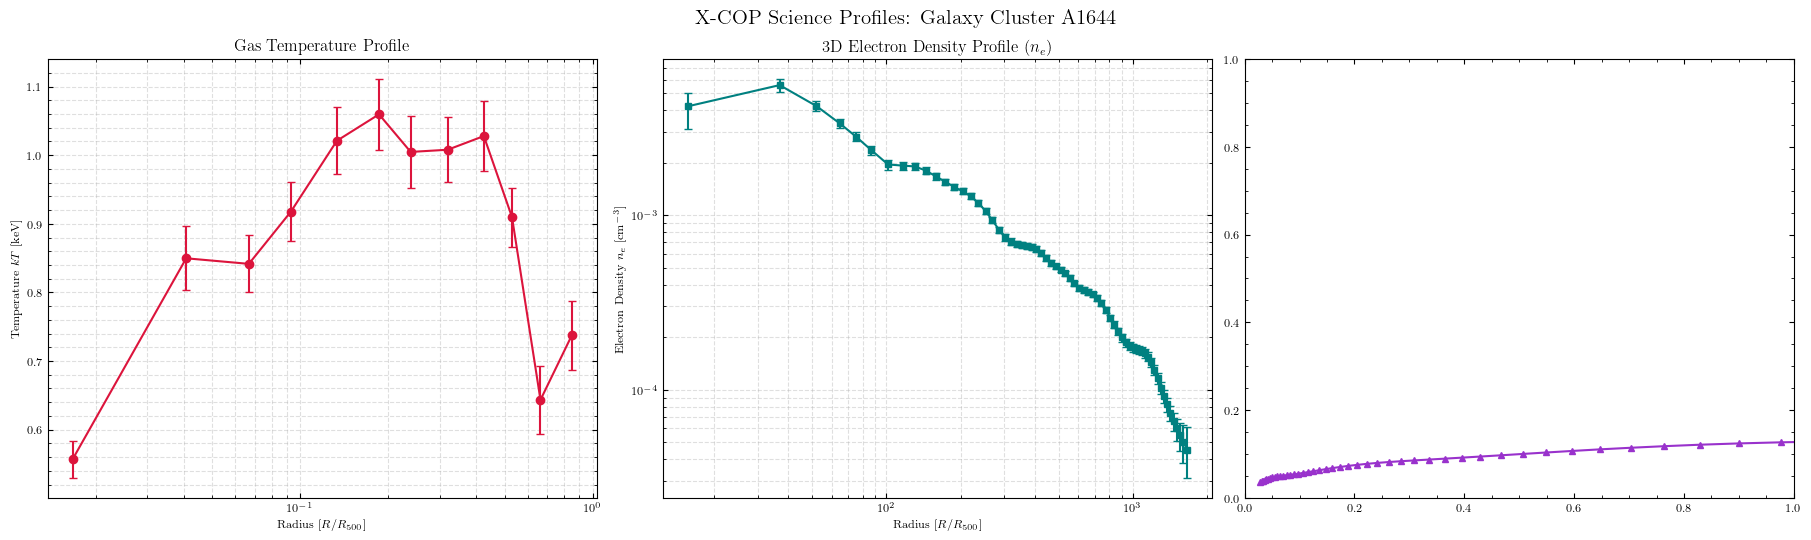

In [70]:
import io
import tarfile
import warnings
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.utils.exceptions import AstropyWarning

# Suppress the verbose FITS unit parsing warnings shown in your terminal logs
warnings.simplefilter('ignore', category=AstropyWarning)

# =====================================================================
# CONFIGURATION
# =====================================================================
tar_path = "chandra/allfiles.tar.gz"
target_cluster = "A1644"  # Change to any available cluster name from your log

def extract_cluster_tables(tar_filepath, cluster_name):
    """
    Finds and reads the density, temperature, and fgas FITS tables
    for a specific cluster completely in memory.
    """
    data_dict = {'density': None, 'temperature': None, 'fgas': None}
    
    with tarfile.open(tar_filepath, "r:gz") as tar:
        for member in tar.getmembers():
            # Filter by the target cluster's directory/prefix name
            if cluster_name in member.name and member.isfile() and member.name.endswith(".fits"):
                
                # Isolate the file data stream
                file_bytes = tar.extractfile(member).read()
                byte_stream = io.BytesIO(file_bytes)
                
                # Categorize based on file name identifiers
                if "density" in member.name:
                    data_dict['density'] = Table.read(byte_stream, format="fits")
                elif "temperature" in member.name:
                    data_dict['temperature'] = Table.read(byte_stream, format="fits")
                elif "fgas" in member.name:
                    data_dict['fgas'] = Table.read(byte_stream, format="fits")
                    
    return data_dict

# Extract the tables straight to variables
cluster_data = extract_cluster_tables(tar_path, target_cluster)

# Verify we successfully collected the necessary datasets
for key, table in cluster_data.items():
    if table is None:
        print(f"⚠️ Warning: Could not find the '{key}' table for cluster {target_cluster}.")
    else:
        print(f"✅ Successfully loaded {key} table ({len(table)} rows).")

# =====================================================================
# INTERACTIVE DATA PLOTTING
# =====================================================================
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"X-COP Science Profiles: Galaxy Cluster {target_cluster}", fontsize=15, y=1.05)

# --- PANEL 1: TEMPERATURE PROFILE ---
if cluster_data['temperature'] is not None:
    t_tab = cluster_data['temperature']
    # Radius column: 'RW_X', Temp: 'T_X', Error: 'eT_X'
    axs[0].errorbar(t_tab['RW_X'], t_tab['T_X'], yerr=t_tab['eT_X'], 
                    fmt='o-', color='crimson', markersize=6, capsize=3, label='X-ray Gas Temp')
    axs[0].set_xscale('log')
    axs[0].set_xlabel("Radius [$R / R_{500}$]")
    axs[0].set_ylabel("Temperature $kT$ [keV]")
    axs[0].set_title("Gas Temperature Profile")
    axs[0].grid(True, which="both", ls="--", alpha=0.4)

# --- PANEL 2: ELECTRON DENSITY PROFILE ---
if cluster_data['density'] is not None:
    n_tab = cluster_data['density']
    # Radial midpoint calculation from R_IN and R_OUT
    r_mid = (n_tab['R_IN'] + n_tab['R_OUT']) / 2.0
    
    # Calculate directional error margins for asymmetric errorbars
    yerr_lower = n_tab['NE'] - n_tab['NE_LOW']
    yerr_upper = n_tab['NE_HIGH'] - n_tab['NE']
    
    axs[1].errorbar(r_mid, n_tab['NE'], yerr=[yerr_lower, yerr_upper], 
                    fmt='s-', color='teal', markersize=5, capsize=3, label='De-projected $n_e$')
    axs[1].set_xscale('log')
    axs[1].set_yscale('log')
    axs[1].set_xlabel("Radius [$R / R_{500}$]")
    axs[1].set_ylabel("Electron Density $n_e$ [$\mathrm{cm}^{-3}$]")
    axs[1].set_title("3D Electron Density Profile ($n_e$)")
    axs[1].grid(True, which="both", ls="--", alpha=0.4)

# --- PANEL 3: GAS MASS FRACTION PROFILE ---
if cluster_data['fgas'] is not None:
    f_tab = cluster_data['fgas']
    f_err_lower = f_tab['FGAS'] - f_tab['FGAS_LO']
    f_err_upper = f_tab['FGAS_HI'] - f_tab['FGAS']
    
    axs[2].errorbar(f_tab['RADIUS'], f_tab['FGAS'], yerr=[f_err_lower, f_err_upper], 
                    fmt='^-', color='darkorchid', markersize=5, capsize=3, label='$f_{gas} = M_{gas}/M_{tot}$')
    axs[2].set_xscale('log')
    axs[2].set_xlabel("Radius [$R / R_{500}$]")
    axs[2].set_ylabel("Gas Mass Fraction $f_{gas}$")
    axs[2].set_title("Gas Mass Fraction Profile")
    axs[2].grid(True, which="both", ls="--", alpha=0.4)

plt.tight_layout()
plt.show()

<>:87: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:87: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_8093/2042103374.py:87: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  axs[1].set_ylabel("Electron Density $n_e$ [$\mathrm{cm}^{-3}$]")


✅ Successfully loaded density table (63 rows).
✅ Successfully loaded temperature table (14 rows).
✅ Successfully loaded fgas table (50 rows).


/tmp/ipykernel_8093/2042103374.py:87: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  axs[1].set_ylabel("Electron Density $n_e$ [$\mathrm{cm}^{-3}$]")


ValueError: 'yerr' must not contain negative values

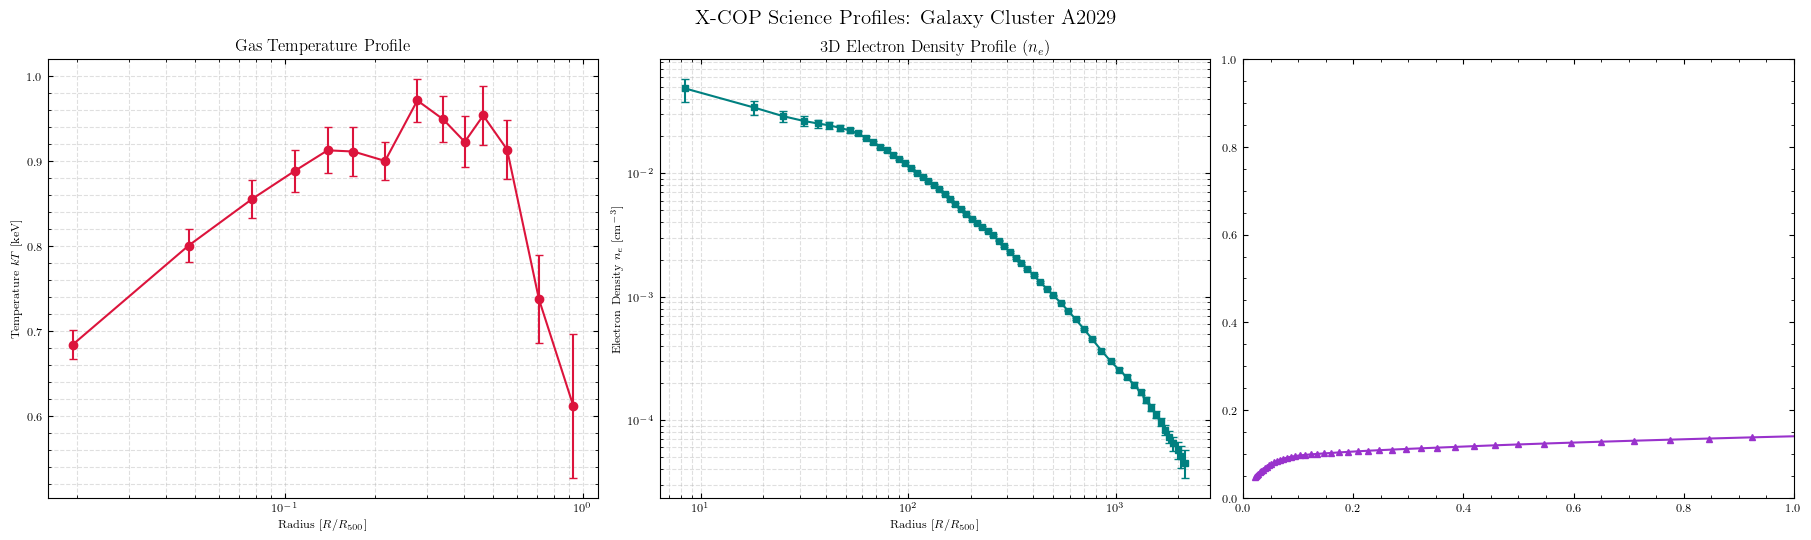

In [71]:
import io
import tarfile
import warnings
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.utils.exceptions import AstropyWarning

# Suppress the verbose FITS unit parsing warnings shown in your terminal logs
warnings.simplefilter('ignore', category=AstropyWarning)

# =====================================================================
# CONFIGURATION
# =====================================================================
tar_path = "chandra/allfiles.tar.gz"
target_cluster = "A2029"  # Change to any available cluster name from your log

def extract_cluster_tables(tar_filepath, cluster_name):
    """
    Finds and reads the density, temperature, and fgas FITS tables
    for a specific cluster completely in memory.
    """
    data_dict = {'density': None, 'temperature': None, 'fgas': None}
    
    with tarfile.open(tar_filepath, "r:gz") as tar:
        for member in tar.getmembers():
            # Filter by the target cluster's directory/prefix name
            if cluster_name in member.name and member.isfile() and member.name.endswith(".fits"):
                
                # Isolate the file data stream
                file_bytes = tar.extractfile(member).read()
                byte_stream = io.BytesIO(file_bytes)
                
                # Categorize based on file name identifiers
                if "density" in member.name:
                    data_dict['density'] = Table.read(byte_stream, format="fits")
                elif "temperature" in member.name:
                    data_dict['temperature'] = Table.read(byte_stream, format="fits")
                elif "fgas" in member.name:
                    data_dict['fgas'] = Table.read(byte_stream, format="fits")
                    
    return data_dict

# Extract the tables straight to variables
cluster_data = extract_cluster_tables(tar_path, target_cluster)

# Verify we successfully collected the necessary datasets
for key, table in cluster_data.items():
    if table is None:
        print(f"⚠️ Warning: Could not find the '{key}' table for cluster {target_cluster}.")
    else:
        print(f"✅ Successfully loaded {key} table ({len(table)} rows).")

# =====================================================================
# INTERACTIVE DATA PLOTTING
# =====================================================================
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"X-COP Science Profiles: Galaxy Cluster {target_cluster}", fontsize=15, y=1.05)

# --- PANEL 1: TEMPERATURE PROFILE ---
if cluster_data['temperature'] is not None:
    t_tab = cluster_data['temperature']
    # Radius column: 'RW_X', Temp: 'T_X', Error: 'eT_X'
    axs[0].errorbar(t_tab['RW_X'], t_tab['T_X'], yerr=t_tab['eT_X'], 
                    fmt='o-', color='crimson', markersize=6, capsize=3, label='X-ray Gas Temp')
    axs[0].set_xscale('log')
    axs[0].set_xlabel("Radius [$R / R_{500}$]")
    axs[0].set_ylabel("Temperature $kT$ [keV]")
    axs[0].set_title("Gas Temperature Profile")
    axs[0].grid(True, which="both", ls="--", alpha=0.4)

# --- PANEL 2: ELECTRON DENSITY PROFILE ---
if cluster_data['density'] is not None:
    n_tab = cluster_data['density']
    # Radial midpoint calculation from R_IN and R_OUT
    r_mid = (n_tab['R_IN'] + n_tab['R_OUT']) / 2.0
    
    # Calculate directional error margins for asymmetric errorbars
    yerr_lower = n_tab['NE'] - n_tab['NE_LOW']
    yerr_upper = n_tab['NE_HIGH'] - n_tab['NE']
    
    axs[1].errorbar(r_mid, n_tab['NE'], yerr=[yerr_lower, yerr_upper], 
                    fmt='s-', color='teal', markersize=5, capsize=3, label='De-projected $n_e$')
    axs[1].set_xscale('log')
    axs[1].set_yscale('log')
    axs[1].set_xlabel("Radius [$R / R_{500}$]")
    axs[1].set_ylabel("Electron Density $n_e$ [$\mathrm{cm}^{-3}$]")
    axs[1].set_title("3D Electron Density Profile ($n_e$)")
    axs[1].grid(True, which="both", ls="--", alpha=0.4)

# --- PANEL 3: GAS MASS FRACTION PROFILE ---
if cluster_data['fgas'] is not None:
    f_tab = cluster_data['fgas']
    f_err_lower = f_tab['FGAS'] - f_tab['FGAS_LO']
    f_err_upper = f_tab['FGAS_HI'] - f_tab['FGAS']
    
    axs[2].errorbar(f_tab['RADIUS'], f_tab['FGAS'], yerr=[f_err_lower, f_err_upper], 
                    fmt='^-', color='darkorchid', markersize=5, capsize=3, label='$f_{gas} = M_{gas}/M_{tot}$')
    axs[2].set_xscale('log')
    axs[2].set_xlabel("Radius [$R / R_{500}$]")
    axs[2].set_ylabel("Gas Mass Fraction $f_{gas}$")
    axs[2].set_title("Gas Mass Fraction Profile")
    axs[2].grid(True, which="both", ls="--", alpha=0.4)

plt.tight_layout()
plt.show()

<>:87: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:87: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_8093/3699116609.py:87: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  axs[1].set_ylabel("Electron Density $n_e$ [$\mathrm{cm}^{-3}$]")


✅ Successfully loaded density table (68 rows).
✅ Successfully loaded temperature table (11 rows).
✅ Successfully loaded fgas table (50 rows).


/tmp/ipykernel_8093/3699116609.py:87: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  axs[1].set_ylabel("Electron Density $n_e$ [$\mathrm{cm}^{-3}$]")


ValueError: 'yerr' must not contain negative values

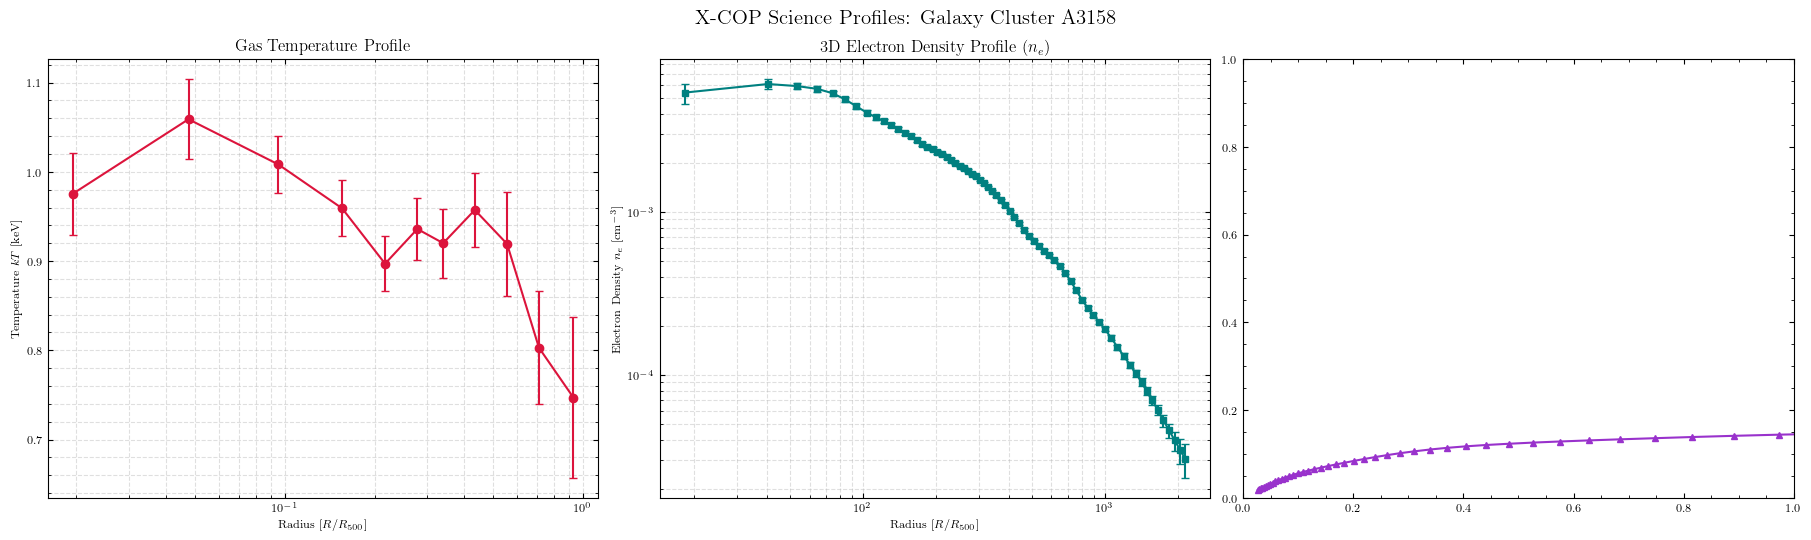

In [72]:
import io
import tarfile
import warnings
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.utils.exceptions import AstropyWarning

# Suppress the verbose FITS unit parsing warnings shown in your terminal logs
warnings.simplefilter('ignore', category=AstropyWarning)

# =====================================================================
# CONFIGURATION
# =====================================================================
tar_path = "chandra/allfiles.tar.gz"
target_cluster = "A3158"  # Change to any available cluster name from your log

def extract_cluster_tables(tar_filepath, cluster_name):
    """
    Finds and reads the density, temperature, and fgas FITS tables
    for a specific cluster completely in memory.
    """
    data_dict = {'density': None, 'temperature': None, 'fgas': None}
    
    with tarfile.open(tar_filepath, "r:gz") as tar:
        for member in tar.getmembers():
            # Filter by the target cluster's directory/prefix name
            if cluster_name in member.name and member.isfile() and member.name.endswith(".fits"):
                
                # Isolate the file data stream
                file_bytes = tar.extractfile(member).read()
                byte_stream = io.BytesIO(file_bytes)
                
                # Categorize based on file name identifiers
                if "density" in member.name:
                    data_dict['density'] = Table.read(byte_stream, format="fits")
                elif "temperature" in member.name:
                    data_dict['temperature'] = Table.read(byte_stream, format="fits")
                elif "fgas" in member.name:
                    data_dict['fgas'] = Table.read(byte_stream, format="fits")
                    
    return data_dict

# Extract the tables straight to variables
cluster_data = extract_cluster_tables(tar_path, target_cluster)

# Verify we successfully collected the necessary datasets
for key, table in cluster_data.items():
    if table is None:
        print(f"⚠️ Warning: Could not find the '{key}' table for cluster {target_cluster}.")
    else:
        print(f"✅ Successfully loaded {key} table ({len(table)} rows).")

# =====================================================================
# INTERACTIVE DATA PLOTTING
# =====================================================================
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"X-COP Science Profiles: Galaxy Cluster {target_cluster}", fontsize=15, y=1.05)

# --- PANEL 1: TEMPERATURE PROFILE ---
if cluster_data['temperature'] is not None:
    t_tab = cluster_data['temperature']
    # Radius column: 'RW_X', Temp: 'T_X', Error: 'eT_X'
    axs[0].errorbar(t_tab['RW_X'], t_tab['T_X'], yerr=t_tab['eT_X'], 
                    fmt='o-', color='crimson', markersize=6, capsize=3, label='X-ray Gas Temp')
    axs[0].set_xscale('log')
    axs[0].set_xlabel("Radius [$R / R_{500}$]")
    axs[0].set_ylabel("Temperature $kT$ [keV]")
    axs[0].set_title("Gas Temperature Profile")
    axs[0].grid(True, which="both", ls="--", alpha=0.4)

# --- PANEL 2: ELECTRON DENSITY PROFILE ---
if cluster_data['density'] is not None:
    n_tab = cluster_data['density']
    # Radial midpoint calculation from R_IN and R_OUT
    r_mid = (n_tab['R_IN'] + n_tab['R_OUT']) / 2.0
    
    # Calculate directional error margins for asymmetric errorbars
    yerr_lower = n_tab['NE'] - n_tab['NE_LOW']
    yerr_upper = n_tab['NE_HIGH'] - n_tab['NE']
    
    axs[1].errorbar(r_mid, n_tab['NE'], yerr=[yerr_lower, yerr_upper], 
                    fmt='s-', color='teal', markersize=5, capsize=3, label='De-projected $n_e$')
    axs[1].set_xscale('log')
    axs[1].set_yscale('log')
    axs[1].set_xlabel("Radius [$R / R_{500}$]")
    axs[1].set_ylabel("Electron Density $n_e$ [$\mathrm{cm}^{-3}$]")
    axs[1].set_title("3D Electron Density Profile ($n_e$)")
    axs[1].grid(True, which="both", ls="--", alpha=0.4)

# --- PANEL 3: GAS MASS FRACTION PROFILE ---
if cluster_data['fgas'] is not None:
    f_tab = cluster_data['fgas']
    f_err_lower = f_tab['FGAS'] - f_tab['FGAS_LO']
    f_err_upper = f_tab['FGAS_HI'] - f_tab['FGAS']
    
    axs[2].errorbar(f_tab['RADIUS'], f_tab['FGAS'], yerr=[f_err_lower, f_err_upper], 
                    fmt='^-', color='darkorchid', markersize=5, capsize=3, label='$f_{gas} = M_{gas}/M_{tot}$')
    axs[2].set_xscale('log')
    axs[2].set_xlabel("Radius [$R / R_{500}$]")
    axs[2].set_ylabel("Gas Mass Fraction $f_{gas}$")
    axs[2].set_title("Gas Mass Fraction Profile")
    axs[2].grid(True, which="both", ls="--", alpha=0.4)

plt.tight_layout()
plt.show()

<>:87: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:87: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_8093/4270708313.py:87: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  axs[1].set_ylabel("Electron Density $n_e$ [$\mathrm{cm}^{-3}$]")


✅ Successfully loaded density table (69 rows).
✅ Successfully loaded temperature table (12 rows).
✅ Successfully loaded fgas table (50 rows).


/tmp/ipykernel_8093/4270708313.py:87: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  axs[1].set_ylabel("Electron Density $n_e$ [$\mathrm{cm}^{-3}$]")


ValueError: 'yerr' must not contain negative values

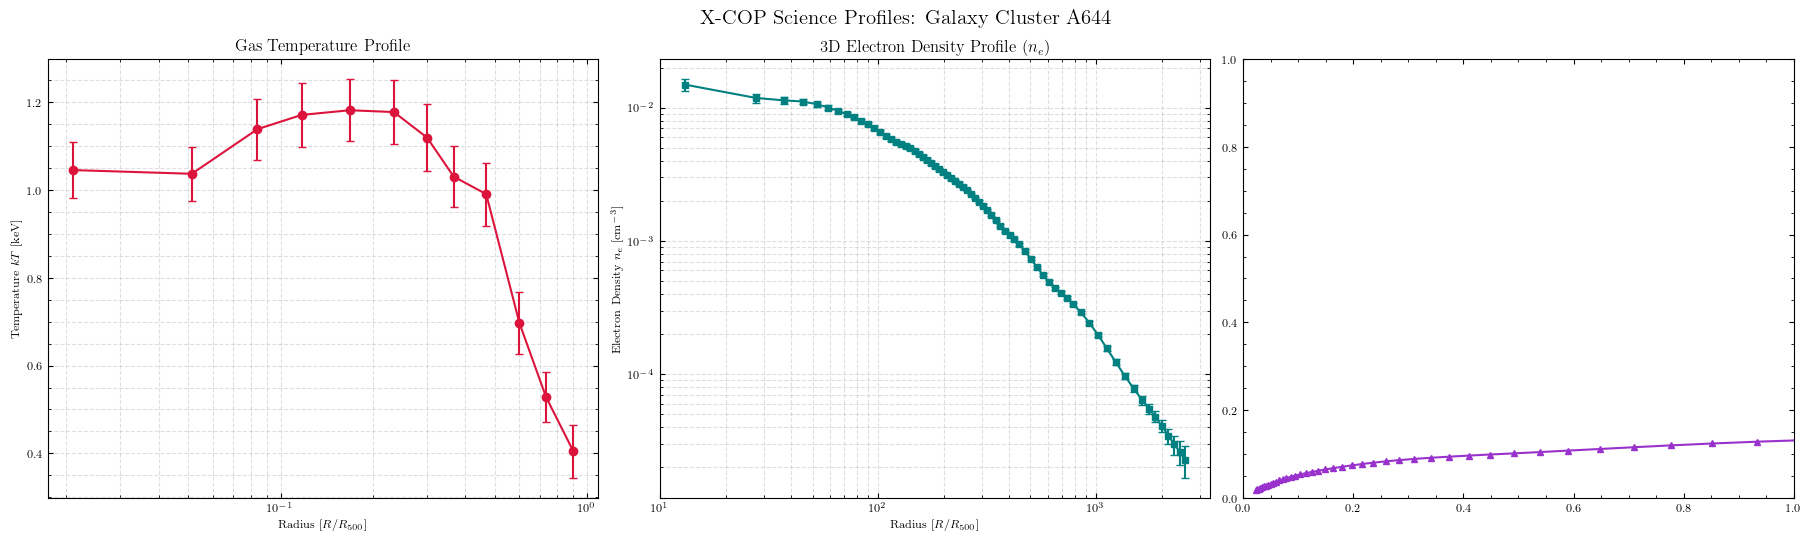

In [73]:
import io
import tarfile
import warnings
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.utils.exceptions import AstropyWarning

# Suppress the verbose FITS unit parsing warnings shown in your terminal logs
warnings.simplefilter('ignore', category=AstropyWarning)

# =====================================================================
# CONFIGURATION
# =====================================================================
tar_path = "chandra/allfiles.tar.gz"
target_cluster = "A644"  # Change to any available cluster name from your log

def extract_cluster_tables(tar_filepath, cluster_name):
    """
    Finds and reads the density, temperature, and fgas FITS tables
    for a specific cluster completely in memory.
    """
    data_dict = {'density': None, 'temperature': None, 'fgas': None}
    
    with tarfile.open(tar_filepath, "r:gz") as tar:
        for member in tar.getmembers():
            # Filter by the target cluster's directory/prefix name
            if cluster_name in member.name and member.isfile() and member.name.endswith(".fits"):
                
                # Isolate the file data stream
                file_bytes = tar.extractfile(member).read()
                byte_stream = io.BytesIO(file_bytes)
                
                # Categorize based on file name identifiers
                if "density" in member.name:
                    data_dict['density'] = Table.read(byte_stream, format="fits")
                elif "temperature" in member.name:
                    data_dict['temperature'] = Table.read(byte_stream, format="fits")
                elif "fgas" in member.name:
                    data_dict['fgas'] = Table.read(byte_stream, format="fits")
                    
    return data_dict

# Extract the tables straight to variables
cluster_data = extract_cluster_tables(tar_path, target_cluster)

# Verify we successfully collected the necessary datasets
for key, table in cluster_data.items():
    if table is None:
        print(f"⚠️ Warning: Could not find the '{key}' table for cluster {target_cluster}.")
    else:
        print(f"✅ Successfully loaded {key} table ({len(table)} rows).")

# =====================================================================
# INTERACTIVE DATA PLOTTING
# =====================================================================
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"X-COP Science Profiles: Galaxy Cluster {target_cluster}", fontsize=15, y=1.05)

# --- PANEL 1: TEMPERATURE PROFILE ---
if cluster_data['temperature'] is not None:
    t_tab = cluster_data['temperature']
    # Radius column: 'RW_X', Temp: 'T_X', Error: 'eT_X'
    axs[0].errorbar(t_tab['RW_X'], t_tab['T_X'], yerr=t_tab['eT_X'], 
                    fmt='o-', color='crimson', markersize=6, capsize=3, label='X-ray Gas Temp')
    axs[0].set_xscale('log')
    axs[0].set_xlabel("Radius [$R / R_{500}$]")
    axs[0].set_ylabel("Temperature $kT$ [keV]")
    axs[0].set_title("Gas Temperature Profile")
    axs[0].grid(True, which="both", ls="--", alpha=0.4)

# --- PANEL 2: ELECTRON DENSITY PROFILE ---
if cluster_data['density'] is not None:
    n_tab = cluster_data['density']
    # Radial midpoint calculation from R_IN and R_OUT
    r_mid = (n_tab['R_IN'] + n_tab['R_OUT']) / 2.0
    
    # Calculate directional error margins for asymmetric errorbars
    yerr_lower = n_tab['NE'] - n_tab['NE_LOW']
    yerr_upper = n_tab['NE_HIGH'] - n_tab['NE']
    
    axs[1].errorbar(r_mid, n_tab['NE'], yerr=[yerr_lower, yerr_upper], 
                    fmt='s-', color='teal', markersize=5, capsize=3, label='De-projected $n_e$')
    axs[1].set_xscale('log')
    axs[1].set_yscale('log')
    axs[1].set_xlabel("Radius [$R / R_{500}$]")
    axs[1].set_ylabel("Electron Density $n_e$ [$\mathrm{cm}^{-3}$]")
    axs[1].set_title("3D Electron Density Profile ($n_e$)")
    axs[1].grid(True, which="both", ls="--", alpha=0.4)

# --- PANEL 3: GAS MASS FRACTION PROFILE ---
if cluster_data['fgas'] is not None:
    f_tab = cluster_data['fgas']
    f_err_lower = f_tab['FGAS'] - f_tab['FGAS_LO']
    f_err_upper = f_tab['FGAS_HI'] - f_tab['FGAS']
    
    axs[2].errorbar(f_tab['RADIUS'], f_tab['FGAS'], yerr=[f_err_lower, f_err_upper], 
                    fmt='^-', color='darkorchid', markersize=5, capsize=3, label='$f_{gas} = M_{gas}/M_{tot}$')
    axs[2].set_xscale('log')
    axs[2].set_xlabel("Radius [$R / R_{500}$]")
    axs[2].set_ylabel("Gas Mass Fraction $f_{gas}$")
    axs[2].set_title("Gas Mass Fraction Profile")
    axs[2].grid(True, which="both", ls="--", alpha=0.4)

plt.tight_layout()
plt.show()

<>:87: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:87: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_8093/4266538870.py:87: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  axs[1].set_ylabel("Electron Density $n_e$ [$\mathrm{cm}^{-3}$]")


✅ Successfully loaded density table (69 rows).
✅ Successfully loaded temperature table (13 rows).
✅ Successfully loaded fgas table (50 rows).


/tmp/ipykernel_8093/4266538870.py:87: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  axs[1].set_ylabel("Electron Density $n_e$ [$\mathrm{cm}^{-3}$]")


ValueError: 'yerr' must not contain negative values

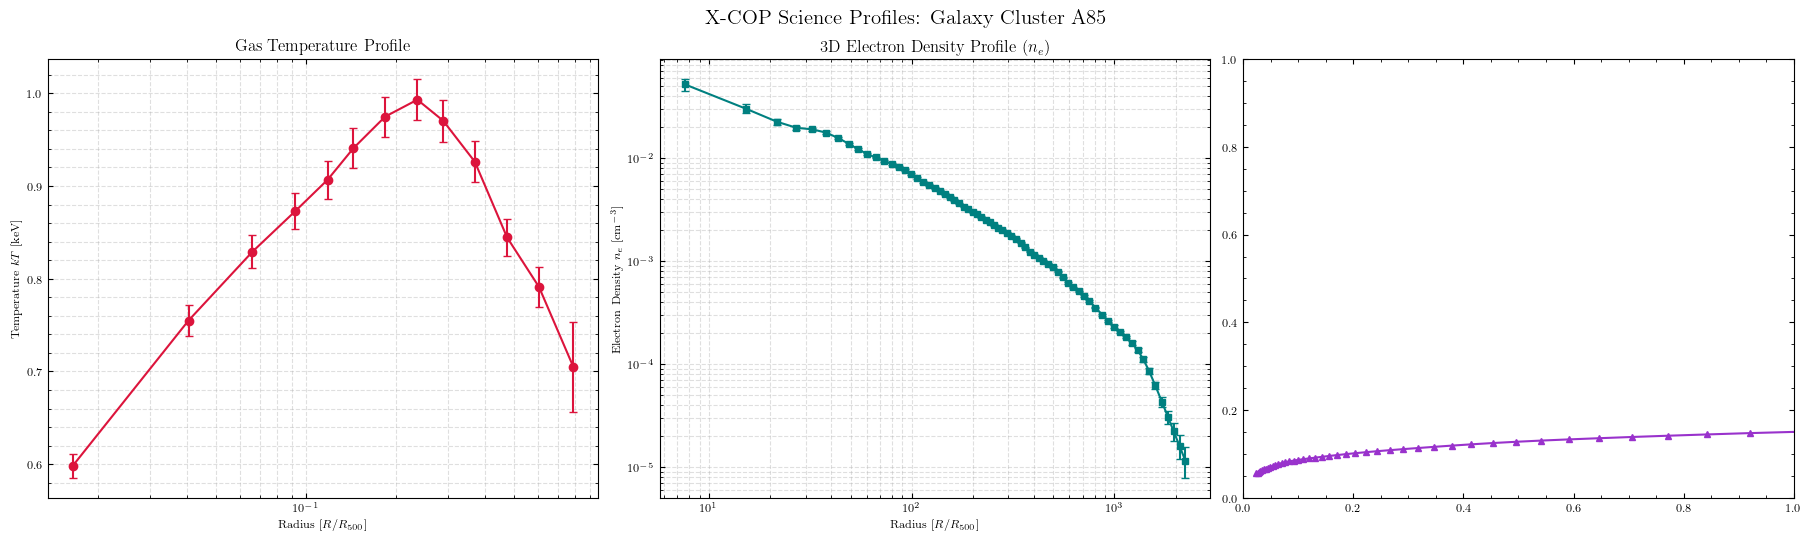

In [74]:
import io
import tarfile
import warnings
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.utils.exceptions import AstropyWarning

# Suppress the verbose FITS unit parsing warnings shown in your terminal logs
warnings.simplefilter('ignore', category=AstropyWarning)

# =====================================================================
# CONFIGURATION
# =====================================================================
tar_path = "chandra/allfiles.tar.gz"
target_cluster = "A85"  # Change to any available cluster name from your log

def extract_cluster_tables(tar_filepath, cluster_name):
    """
    Finds and reads the density, temperature, and fgas FITS tables
    for a specific cluster completely in memory.
    """
    data_dict = {'density': None, 'temperature': None, 'fgas': None}
    
    with tarfile.open(tar_filepath, "r:gz") as tar:
        for member in tar.getmembers():
            # Filter by the target cluster's directory/prefix name
            if cluster_name in member.name and member.isfile() and member.name.endswith(".fits"):
                
                # Isolate the file data stream
                file_bytes = tar.extractfile(member).read()
                byte_stream = io.BytesIO(file_bytes)
                
                # Categorize based on file name identifiers
                if "density" in member.name:
                    data_dict['density'] = Table.read(byte_stream, format="fits")
                elif "temperature" in member.name:
                    data_dict['temperature'] = Table.read(byte_stream, format="fits")
                elif "fgas" in member.name:
                    data_dict['fgas'] = Table.read(byte_stream, format="fits")
                    
    return data_dict

# Extract the tables straight to variables
cluster_data = extract_cluster_tables(tar_path, target_cluster)

# Verify we successfully collected the necessary datasets
for key, table in cluster_data.items():
    if table is None:
        print(f"⚠️ Warning: Could not find the '{key}' table for cluster {target_cluster}.")
    else:
        print(f"✅ Successfully loaded {key} table ({len(table)} rows).")

# =====================================================================
# INTERACTIVE DATA PLOTTING
# =====================================================================
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"X-COP Science Profiles: Galaxy Cluster {target_cluster}", fontsize=15, y=1.05)

# --- PANEL 1: TEMPERATURE PROFILE ---
if cluster_data['temperature'] is not None:
    t_tab = cluster_data['temperature']
    # Radius column: 'RW_X', Temp: 'T_X', Error: 'eT_X'
    axs[0].errorbar(t_tab['RW_X'], t_tab['T_X'], yerr=t_tab['eT_X'], 
                    fmt='o-', color='crimson', markersize=6, capsize=3, label='X-ray Gas Temp')
    axs[0].set_xscale('log')
    axs[0].set_xlabel("Radius [$R / R_{500}$]")
    axs[0].set_ylabel("Temperature $kT$ [keV]")
    axs[0].set_title("Gas Temperature Profile")
    axs[0].grid(True, which="both", ls="--", alpha=0.4)

# --- PANEL 2: ELECTRON DENSITY PROFILE ---
if cluster_data['density'] is not None:
    n_tab = cluster_data['density']
    # Radial midpoint calculation from R_IN and R_OUT
    r_mid = (n_tab['R_IN'] + n_tab['R_OUT']) / 2.0
    
    # Calculate directional error margins for asymmetric errorbars
    yerr_lower = n_tab['NE'] - n_tab['NE_LOW']
    yerr_upper = n_tab['NE_HIGH'] - n_tab['NE']
    
    axs[1].errorbar(r_mid, n_tab['NE'], yerr=[yerr_lower, yerr_upper], 
                    fmt='s-', color='teal', markersize=5, capsize=3, label='De-projected $n_e$')
    axs[1].set_xscale('log')
    axs[1].set_yscale('log')
    axs[1].set_xlabel("Radius [$R / R_{500}$]")
    axs[1].set_ylabel("Electron Density $n_e$ [$\mathrm{cm}^{-3}$]")
    axs[1].set_title("3D Electron Density Profile ($n_e$)")
    axs[1].grid(True, which="both", ls="--", alpha=0.4)

# --- PANEL 3: GAS MASS FRACTION PROFILE ---
if cluster_data['fgas'] is not None:
    f_tab = cluster_data['fgas']
    f_err_lower = f_tab['FGAS'] - f_tab['FGAS_LO']
    f_err_upper = f_tab['FGAS_HI'] - f_tab['FGAS']
    
    axs[2].errorbar(f_tab['RADIUS'], f_tab['FGAS'], yerr=[f_err_lower, f_err_upper], 
                    fmt='^-', color='darkorchid', markersize=5, capsize=3, label='$f_{gas} = M_{gas}/M_{tot}$')
    axs[2].set_xscale('log')
    axs[2].set_xlabel("Radius [$R / R_{500}$]")
    axs[2].set_ylabel("Gas Mass Fraction $f_{gas}$")
    axs[2].set_title("Gas Mass Fraction Profile")
    axs[2].grid(True, which="both", ls="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
import io
import tarfile
import warnings
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.utils.exceptions import AstropyWarning

# Suppress the verbose FITS unit parsing warnings shown in your terminal logs
warnings.simplefilter('ignore', category=AstropyWarning)

# =====================================================================
# CONFIGURATION
# =====================================================================
tar_path = "chandra/allfiles.tar.gz"
target_cluster = "A85"  # Change to any available cluster name from your log

def extract_cluster_tables(target):
    data_dict = {'density': None, 'temperature': None, 'fgas': None}
    
    with tarfile.open('catalog/XMM-Newton/X-COM.tar.gz', 'r:gz') as tar:
        for member in tar.getmembers():
            if target in member.name and member.isfile() and member.name.endswith(".fits"):
                
                file_bytes = tar.extractfile(member).read()
                byte_stream = io.BytesIO(file_bytes)
                
                if 'density' in member.name:
                    data_dict['density'] = Table.read(byte_stream, format='fits')
                elif 'temperature' in member.name:
                    data_dict['temperature'] = Table.read(byte_stream, format='fits')
                elif 'fgas' in member.name:
                    data_dict['fgas'] = Table.read(byte_stream, format='fits')
                    
    return data_dict

# Extract the tables straight to variables
cluster_data = extract_cluster_tables(tar_path, target_cluster)

# Verify we successfully collected the necessary datasets
for key, table in cluster_data.items():
    if table is None:
        print(f"⚠️ Warning: Could not find the '{key}' table for cluster {target_cluster}.")
    else:
        print(f"✅ Successfully loaded {key} table ({len(table)} rows).")

# =====================================================================
# INTERACTIVE DATA PLOTTING
# =====================================================================
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"X-COP Science Profiles: Galaxy Cluster {target_cluster}", fontsize=15, y=1.05)

# --- PANEL 1: TEMPERATURE PROFILE ---
if cluster_data['temperature'] is not None:
    t_tab = cluster_data['temperature']
    # Radius column: 'RW_X', Temp: 'T_X', Error: 'eT_X'
    axs[0].errorbar(t_tab['RW_X'], t_tab['T_X'], yerr=t_tab['eT_X'], 
                    fmt='o-', color='crimson', markersize=6, capsize=3, label='X-ray Gas Temp')
    axs[0].set_xscale('log')
    axs[0].set_xlabel("Radius [$R / R_{500}$]")
    axs[0].set_ylabel("Temperature $kT$ [keV]")
    axs[0].set_title("Gas Temperature Profile")
    axs[0].grid(True, which="both", ls="--", alpha=0.4)

# --- PANEL 2: ELECTRON DENSITY PROFILE ---
if cluster_data['density'] is not None:
    n_tab = cluster_data['density']
    # Radial midpoint calculation from R_IN and R_OUT
    r_mid = (n_tab['R_IN'] + n_tab['R_OUT']) / 2.0
    
    # Calculate directional error margins for asymmetric errorbars
    yerr_lower = n_tab['NE'] - n_tab['NE_LOW']
    yerr_upper = n_tab['NE_HIGH'] - n_tab['NE']
    
    axs[1].errorbar(r_mid, n_tab['NE'], yerr=[yerr_lower, yerr_upper], 
                    fmt='s-', color='teal', markersize=5, capsize=3, label='De-projected $n_e$')
    axs[1].set_xscale('log')
    axs[1].set_yscale('log')
    axs[1].set_xlabel("Radius [$R / R_{500}$]")
    axs[1].set_ylabel("Electron Density $n_e$ [$\mathrm{cm}^{-3}$]")
    axs[1].set_title("3D Electron Density Profile ($n_e$)")
    axs[1].grid(True, which="both", ls="--", alpha=0.4)

# --- PANEL 3: GAS MASS FRACTION PROFILE ---
if cluster_data['fgas'] is not None:
    f_tab = cluster_data['fgas']
    f_err_lower = f_tab['FGAS'] - f_tab['FGAS_LO']
    f_err_upper = f_tab['FGAS_HI'] - f_tab['FGAS']
    
    axs[2].errorbar(f_tab['RADIUS'], f_tab['FGAS'], yerr=[f_err_lower, f_err_upper], 
                    fmt='^-', color='darkorchid', markersize=5, capsize=3, label='$f_{gas} = M_{gas}/M_{tot}$')
    axs[2].set_xscale('log')
    axs[2].set_xlabel("Radius [$R / R_{500}$]")
    axs[2].set_ylabel("Gas Mass Fraction $f_{gas}$")
    axs[2].set_title("Gas Mass Fraction Profile")
    axs[2].grid(True, which="both", ls="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [116]:
def extract(target):
    data = {'density': None, 'temperature': None, 'fgas': None}

    print('streaming data from archive...\n')

    with tarfile.open('catalog/XMM-Newton/X-COP.tar.gz', 'r:gz') as tar:
        for member in tar.getmembers():
            if target in member.name and member.isfile() and member.name.endswith(".fits"):
                
                file_bytes = tar.extractfile(member).read()
                byte_stream = io.BytesIO(file_bytes)
                
                if 'density' in member.name:
                    data['density'] = Table.read(byte_stream, format='fits')
                elif 'temperature' in member.name:
                    data['temperature'] = Table.read(byte_stream, format='fits')
                elif 'fgas' in member.name:
                    data['fgas'] = Table.read(byte_stream, format='fits')

    if data['density'] is not None:
        tab = data['density']

        print('saving density data...\n')

        R = (tab['R_IN'] + tab['R_OUT']) / 2.0
        ne = tab['NE']
        ne_err_lo = np.abs(tab['NE'] - tab['NE_LOW'])
        ne_err_hi = np.abs(tab['NE'] - tab['NE_HIGH'])
    
        output_file = f'X-COM-{target}-dens.txt'
    
        np.savetxt('catalog/XMM-Newton/' + output_file,
                   np.column_stack((R, ne, ne_err_lo, ne_err_hi)),
                   header='R / kpc # ne / cm-3 # ne_err_lo / cm-3 # ne_err_hi / cm-3 #')
    else:
        print('no density data found...\n')

    if data['temperature'] is not None:
        tab = data['temperature']

        print('saving temperature data...\n')
        
        R = tab['RW_X']
        T = tab['T_X']
        T_err = tab['eT_X']
    
        output_file = f'X-COM-{target}-temp.txt'
    
        np.savetxt('catalog/XMM-Newton/' + output_file,
                   np.column_stack((R, T, T_err)),
                   header='R/R500 # T/Tavg # T_err/Tavg #')
    else:
        print('no temperature data found...\n')

    if data['fgas'] is not None:
        tab = data['fgas']

        print('saving fgas data...\n')
    
        R = tab['RADIUS']
        fgas = tab['FGAS']
        fgas_err_lo = np.abs(tab['FGAS'] - tab['FGAS_LO'])
        fgas_err_hi = np.abs(tab['FGAS'] - tab['FGAS_HI'])
    
        output_file = f'X-COM-{target}-fgas.txt'
    
        np.savetxt('catalog/XMM-Newton/' + output_file,
                   np.column_stack((R, fgas, fgas_err_lo, fgas_err_hi)),
                   header='R/R500 # fgas # fgas_err_lo # fgas_err_hi #')
    else:
        print('no fgas data found...\n')

    print('finished.')

In [119]:
extract('A85')

streaming data from archive...

saving density data...

saving temperature data...

saving fgas data...

finished.


In [ ]:
import io
import tarfile
from astropy.io import fits

tar_path = "allfiles.tar.gz"
target_cluster = "A1644"  # Change to whichever cluster you want to inspect

with tarfile.open(tar_path, "r:gz") as tar:
    for member in tar.getmembers():
        # Look for the FITS tables matching our target cluster
        if target_cluster in member.name and member.name.endswith(".fits"):
            
            # Read the file directly from the compressed stream into memory
            file_bytes = tar.extractfile(member).read()
            byte_stream = io.BytesIO(file_bytes)
            
            # Open the FITS file with astropy
            with fits.open(byte_stream) as hdul:
                print(f"\n==================================================")
                print(f"FILE: {member.name}")
                print(f"==================================================")
                
                # HDU 0 or 1 contains the structural metadata header
                # We'll check both the primary header and the data table header
                for i, hdu in enumerate(hdul):
                    header = hdu.header
                    
                    # Print standard metadata keywords if they exist in this file
                    # X-COP commonly uses variants of these keys:
                    keywords_to_check = [
                        'R500', 'R_500', 'M500', 'M_500', 'T_AVG', 'T_500', 
                        'REDSHIFT', 'Z', 'KPC_ARCS', 'SCALE', 'TMAX'
                    ]
                    
                    found_any = False
                    for key in keywords_to_check:
                        if key in header:
                            print(f"  {key:<12} = {header[key]} \t# {header.comments[key]}")
                            found_any = True
                            
                    # If you want to dump the ENTIRE structural header to see 
                    # exactly what hidden constants the pipeline left behind:
                    # print(header.tostring(sep='\n'))
                    
                    if found_any:
                        break # Found the main metadata block, move to next file